In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12

In [26]:
print("="*60)
print("تمرین اول: تحلیل آماری و مصورسازی داده")
print("="*60)
df = pd.read_csv('airport-codes.csv') 

print("="*60)
print("\n سطر اول دیتاست")
print("="*60)
print(df.head(10))
print("="*60)
print("\n اطلاعات دیتاست")
print("="*60)
print(df.info())

تمرین اول: تحلیل آماری و مصورسازی داده

 سطر اول دیتاست
       id ident           type                                name  \
0    6523   00A       heliport                   Total Rf Heliport   
1  323361  00AA  small_airport                Aero B Ranch Airport   
2    6524  00AK  small_airport                        Lowell Field   
3    6525  00AL  small_airport                        Epps Airpark   
4    6526  00AR         closed  Newport Hospital & Clinic Heliport   
5  322127  00AS  small_airport                      Fulton Airport   
6    6527  00AZ  small_airport                      Cordes Airport   
7    6528  00CA  small_airport             Goldstone /Gts/ Airport   
8  324424  00CL  small_airport                 Williams Ag Airport   
9  322658  00CN       heliport     Kitchen Creek Helibase Heliport   

   latitude_deg  longitude_deg  elevation_ft continent iso_country iso_region  \
0     40.070801     -74.933601          11.0       NaN          US      US-PA   
1     38.70

In [16]:
# نمایش ابعاد دیتاست
print(f"\nابعاد دیتاست: {df.shape[0]} سطر و {df.shape[1]} ستون")


ابعاد دیتاست: 57909 سطر و 18 ستون


In [27]:
print("نوع داده‌های هر ستون")
print(df.dtypes)

نوع داده‌های هر ستون
id                     int64
ident                 object
type                  object
name                  object
latitude_deg         float64
longitude_deg        float64
elevation_ft         float64
continent             object
iso_country           object
iso_region            object
municipality          object
scheduled_service     object
gps_code              object
iata_code             object
local_code            object
home_link             object
wikipedia_link        object
keywords              object
dtype: object


In [28]:
# تفکیک ستون‌های عددی و غیرعددی
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nستون‌های عددی: {numeric_cols}")
print(f"ستون‌های دسته‌بندی: {categorical_cols}")


ستون‌های عددی: ['id', 'latitude_deg', 'longitude_deg', 'elevation_ft']
ستون‌های دسته‌بندی: ['ident', 'type', 'name', 'continent', 'iso_country', 'iso_region', 'municipality', 'scheduled_service', 'gps_code', 'iata_code', 'local_code', 'home_link', 'wikipedia_link', 'keywords']


In [32]:
#  توصیفات آماری پایه

print("\n توصیفات آماری پایه")
print("="*60)
# خلاصه آماری کامل
print("\nخلاصه آماری داده‌های عددی")
desc_stats = df[numeric_cols].describe()
print(desc_stats)

# محاسبه واریانس
print("\nواریانس (Variance):")
print(df[numeric_cols].var())

# محاسبه انحراف معیار
print("\nانحراف معیار (Standard Deviation):")
print(df[numeric_cols].std())

# محاسبه چولگی (Skewness)
print("\nچولگی (Skewness):")
print(df[numeric_cols].skew())

# محاسبه کشیدگی (Kurtosis)
print("\nکشیدگی (Kurtosis):")
print(df[numeric_cols].kurtosis())

# محاسبه مد (Mode)
print("\nمد (Mode):")
print(df[numeric_cols].mode().iloc[0])

# محاسبه میانه (Median)
print("\nمیانه (Median):")
print(df[numeric_cols].median())


 توصیفات آماری پایه

خلاصه آماری داده‌های عددی
                  id  latitude_deg  longitude_deg  elevation_ft
count   57909.000000  57909.000000   57909.000000  49817.000000
mean    96005.380321     25.494921     -34.894796   1253.873638
std    129429.639322     27.286100      79.835232   1614.490407
min         2.000000    -90.000000    -179.876999  -1266.000000
25%     14606.000000      7.477794     -92.168198    208.000000
50%     29236.000000     36.116699     -71.475304    724.000000
75%     46333.000000     43.708302      14.300332   1520.000000
max    336313.000000     90.000000     179.999894  29977.000000

واریانس (Variance):
id               1.675203e+10
latitude_deg     7.445312e+02
longitude_deg    6.373664e+03
elevation_ft     2.606579e+06
dtype: float64

انحراف معیار (Standard Deviation):
id               129429.639322
latitude_deg         27.286100
longitude_deg        79.835232
elevation_ft       1614.490407
dtype: float64

چولگی (Skewness):
id               1.163608



خلاصه 5 عددی و نمودار جعبه‌ای:

خلاصه 5 عددی برای id:
  حداقل: 2
  چارک اول (Q1): 14606.0
  میانه (Q2): 29236.0
  چارک سوم (Q3): 46333.0
  حداکثر: 336313
  دامنه میان‌چارکی (IQR):31727.0
 

خلاصه 5 عددی برای latitude_deg:
  حداقل: -90.0
  چارک اول (Q1): 7.47779350981
  میانه (Q2): 36.11669921875
  چارک سوم (Q3): 43.70830154418945
  حداکثر: 90.0
  دامنه میان‌چارکی (IQR):36.230508034379454
 

خلاصه 5 عددی برای longitude_deg:
  حداقل: -179.876998901
  چارک اول (Q1): -92.16819763183594
  میانه (Q2): -71.47530364990234
  چارک سوم (Q3): 14.300332
  حداکثر: 179.999894
  دامنه میان‌چارکی (IQR):106.46852963183593
 

خلاصه 5 عددی برای elevation_ft:
  حداقل: -1266.0
  چارک اول (Q1): 208.0
  میانه (Q2): 724.0
  چارک سوم (Q3): 1520.0
  حداکثر: 29977.0
  دامنه میان‌چارکی (IQR):1312.0
 


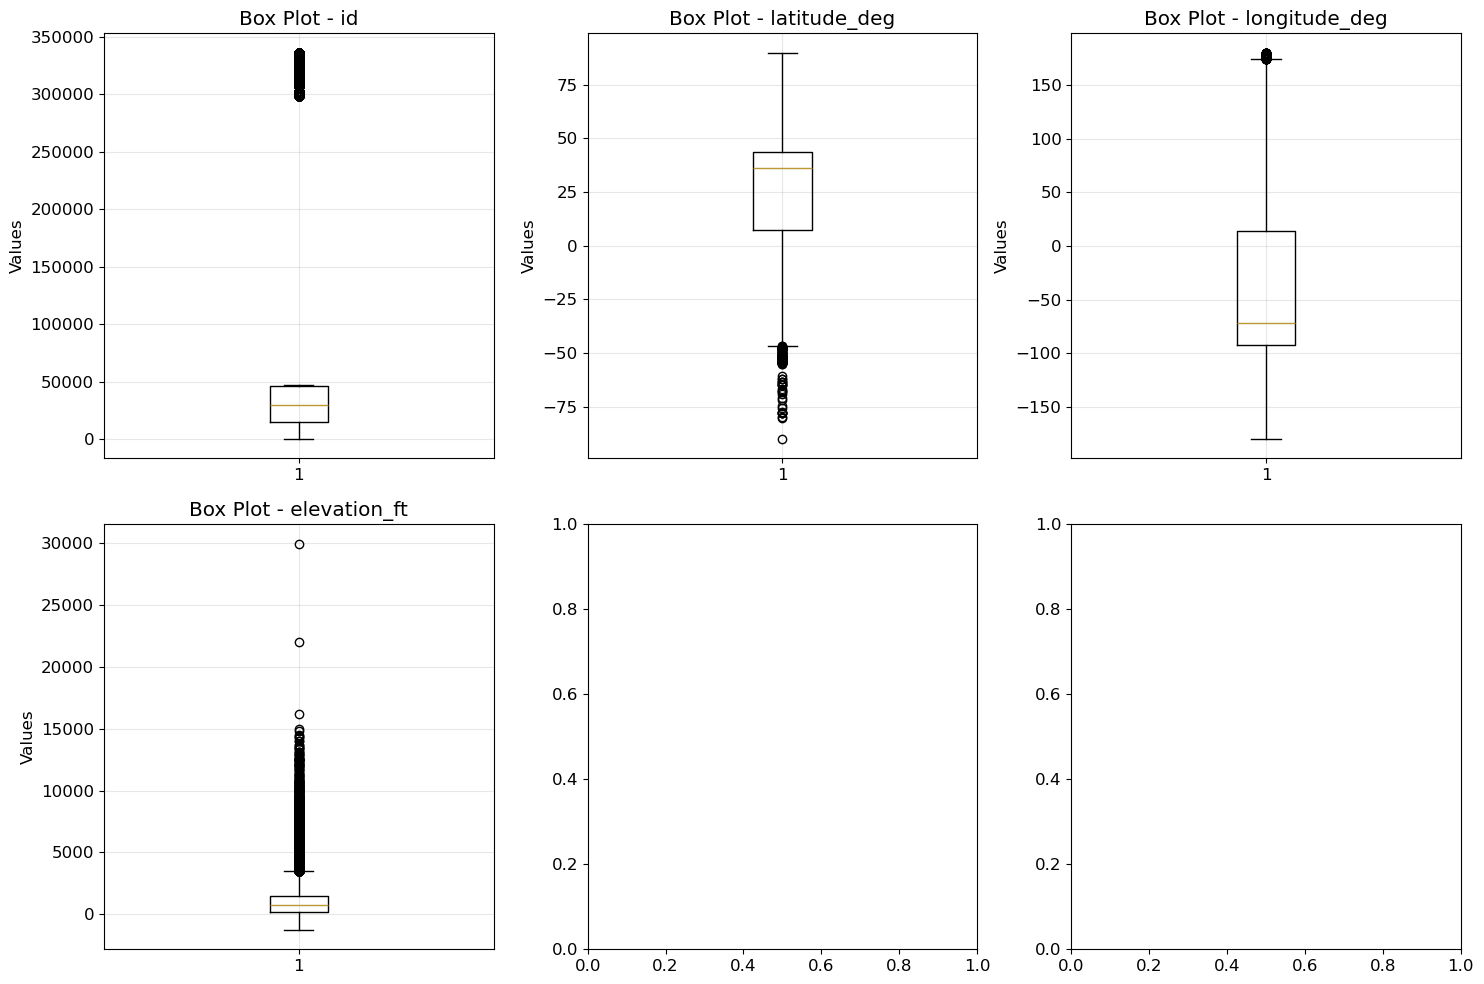

In [36]:
# خلاصه 5 عددی و باکس پلات

print("\nخلاصه 5 عددی و نمودار جعبه‌ای:")
print("="*60)

for col in numeric_cols[:5]:  # محدود به 5 ستون اول
    # محاسبه خلاصه 5 عددی
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"\nخلاصه 5 عددی برای {col}:")
    print(f"  حداقل: {df[col].min()}")
    print(f"  چارک اول (Q1): {Q1}")
    print(f"  میانه (Q2): {df[col].median()}")
    print(f"  چارک سوم (Q3): {Q3}")
    print(f"  حداکثر: {df[col].max()}")
    print(f"  دامنه میان‌چارکی (IQR):{IQR}\n ")

# رسم باکس پلات برای تمام ستون‌های عددی
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Box Plot - {col}')
    axes[idx].set_ylabel('Values')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


رسم هیستوگرام‌ها


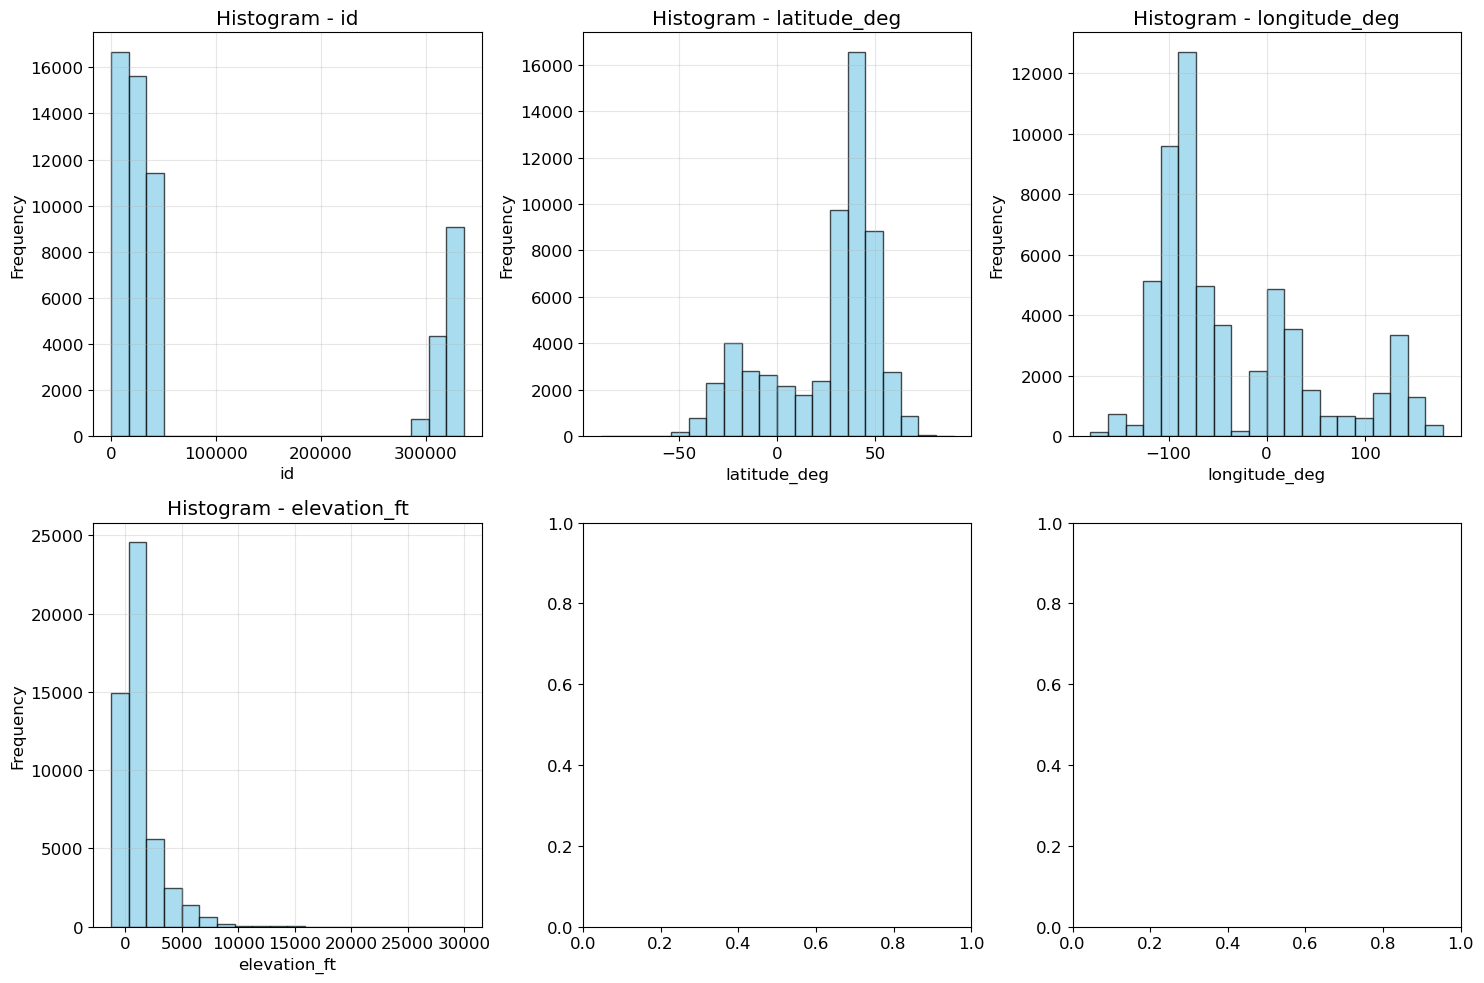

رسم نمودارهای چگالی


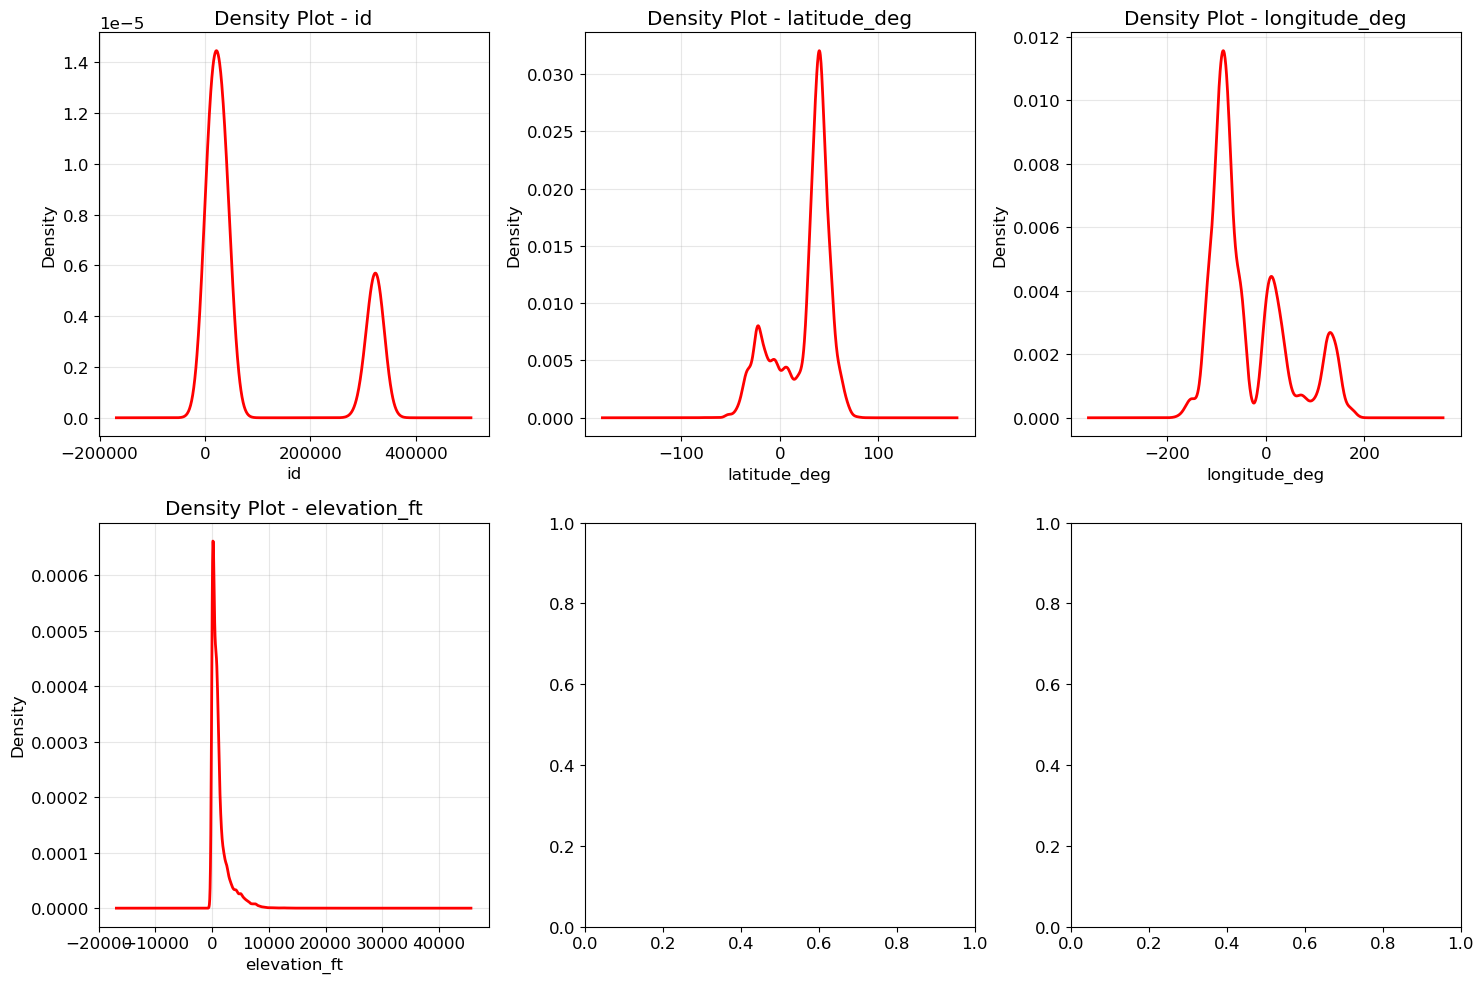

رسم نمودار پراکندگی


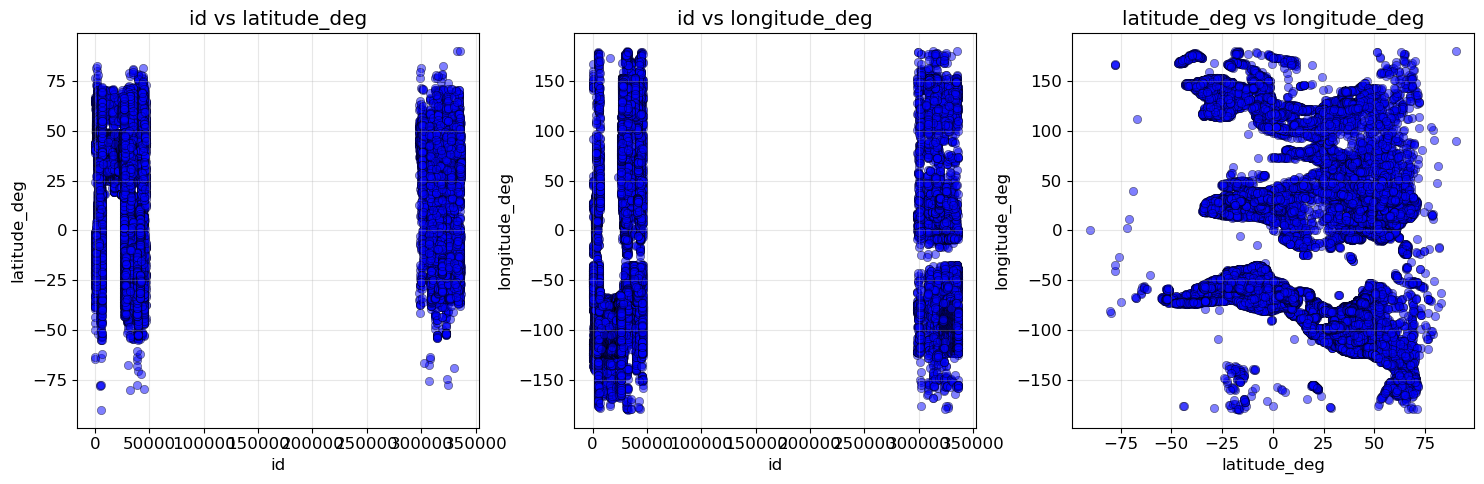

رسم نمودار خطی


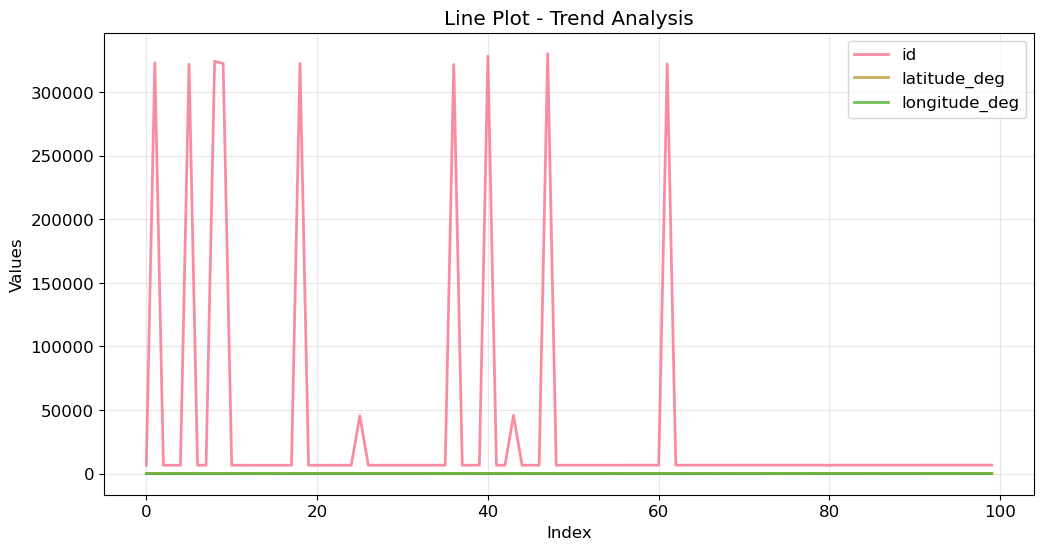

رسم نمودار میله‌ای


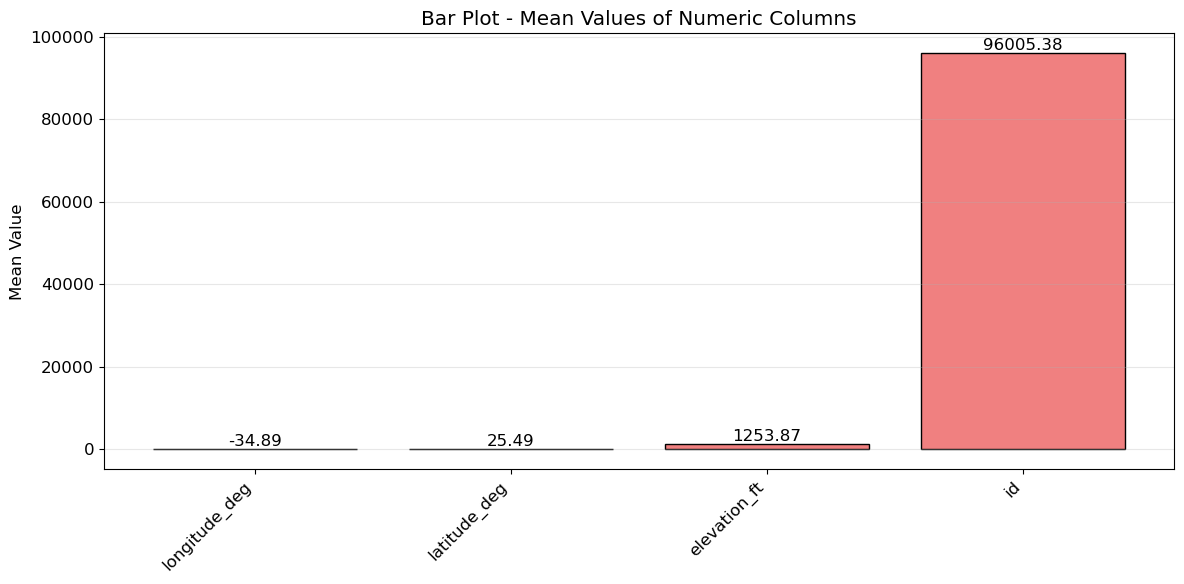

رسم نمودار دایره‌ای


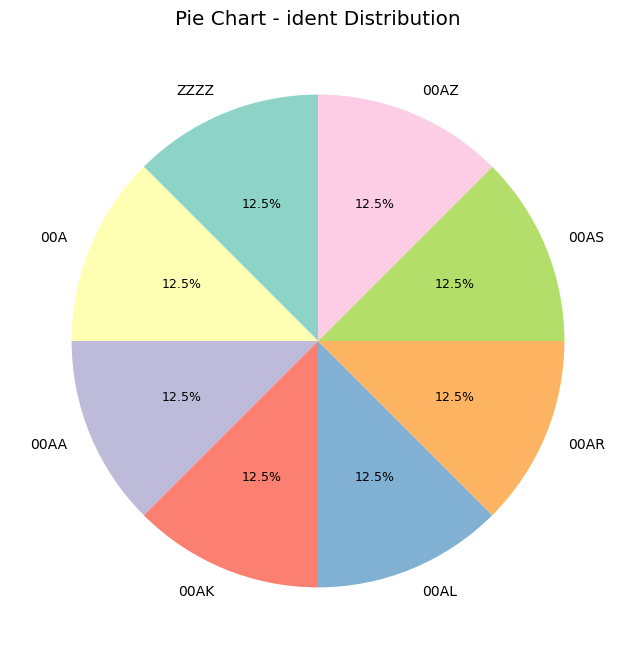

 رسم نقشه گرمایی همبستگی


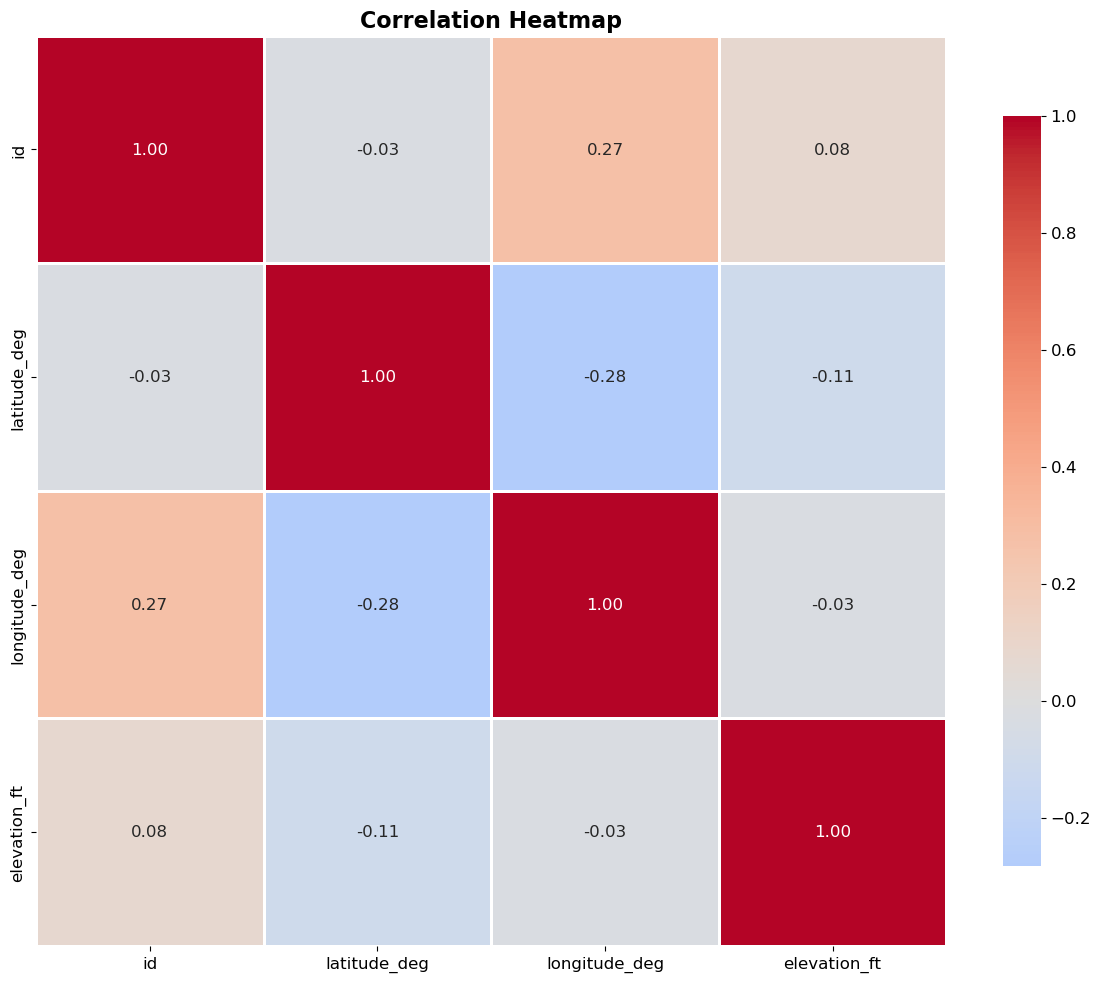

رسم نمودارهای جفتی


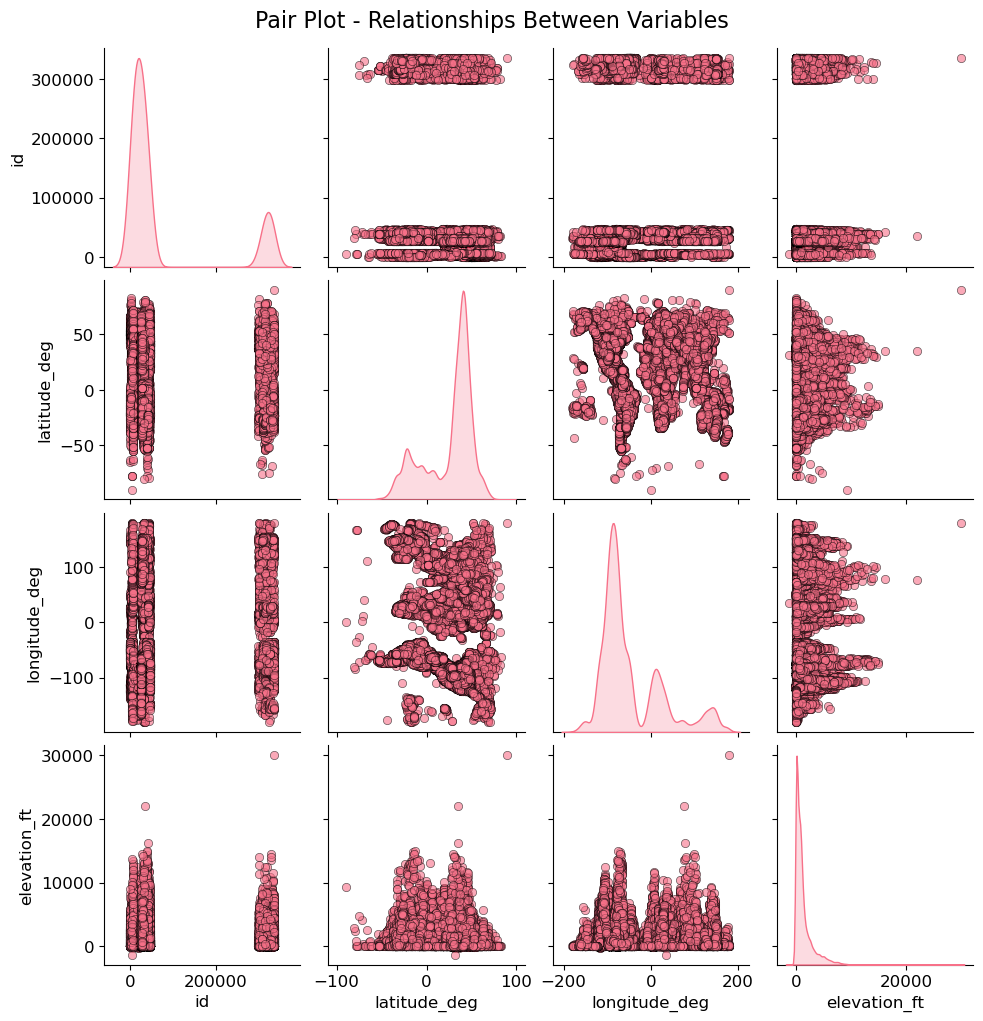

رسم Violin Plot


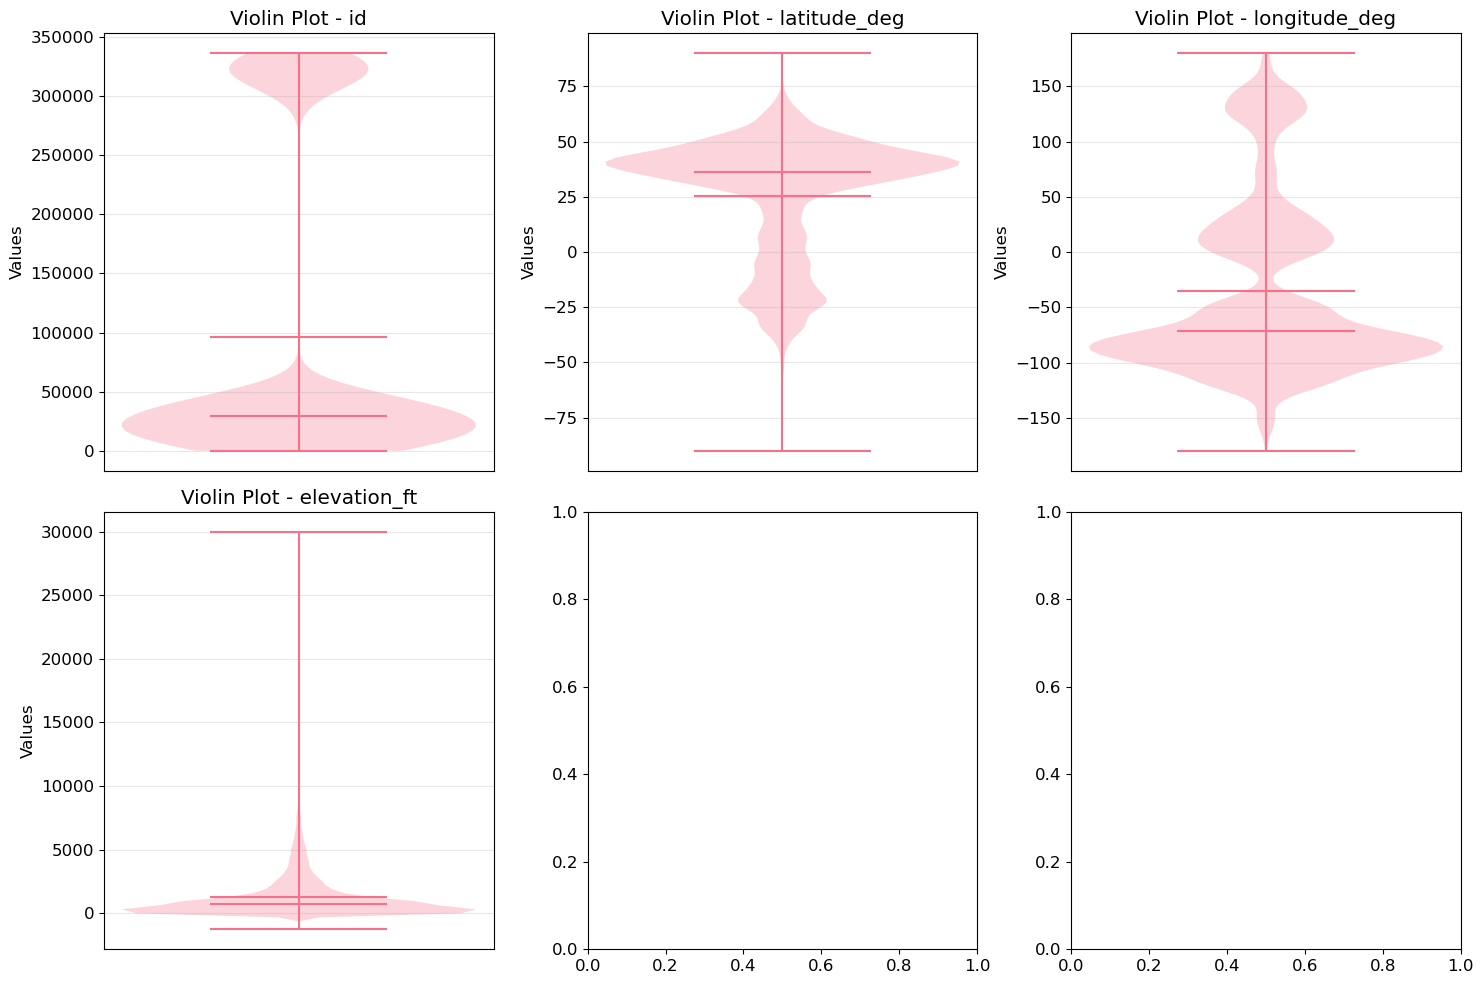


تحلیل داده‌های گمشده:
                Missing Count  Percentage
elevation_ft             8092   13.973648
continent               28741   49.631318
iso_country               246    0.424804
municipality             5891   10.172857
gps_code                16208   27.988741
iata_code               48668   84.042204
local_code              27596   47.654078
home_link               54767   94.574246
wikipedia_link          47841   82.614101
keywords                47172   81.458841


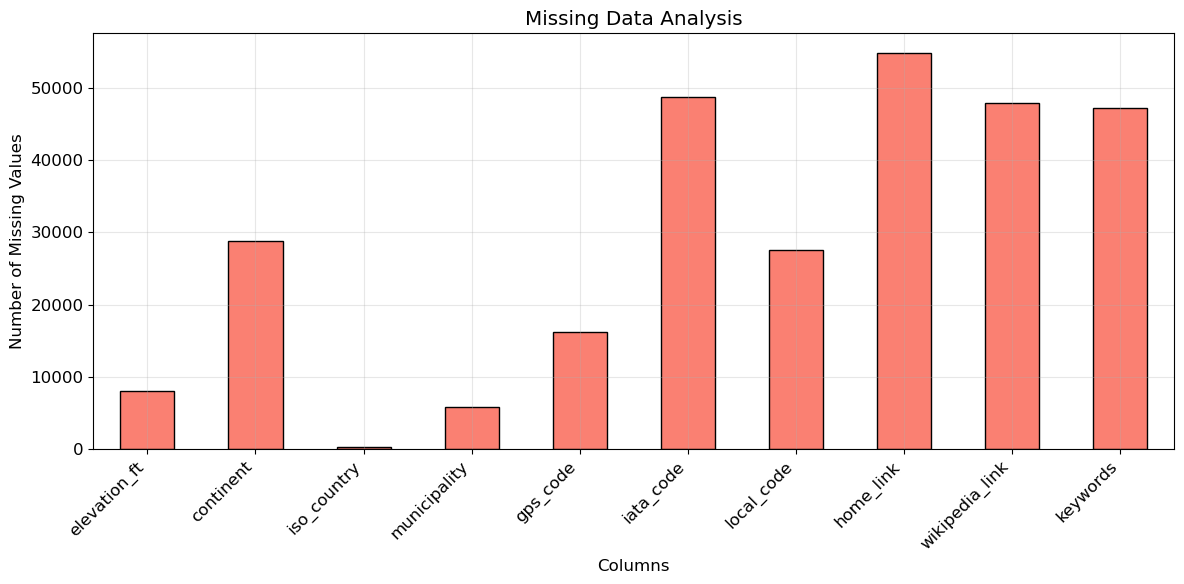


گزارش تحلیل آماری کامل شد!

فایل‌های ذخیره شده:
1. boxplots.png - نمودارهای جعبه‌ای
2. histograms.png - هیستوگرام‌ها
3. density_plots.png - نمودارهای چگالی
4. scatter_plots.png - نمودارهای پراکندگی
5. line_plot.png - نمودار خطی
6. bar_plot.png - نمودار میله‌ای
7. pie_chart.png - نمودار دایره‌ای
8. correlation_heatmap.png - نقشه همبستگی
9. pair_plot.png - نمودارهای جفتی
10. violin_plots.png - نمودارهای ویولن
11. missing_data.png - تحلیل داده‌های گمشده


In [38]:
#  رسم انواع نمودارها


# -----هیستوگرام-----
print("رسم هیستوگرام‌ها")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Histogram - {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograms.png', dpi=300, bbox_inches='tight')
plt.show()

# -----نمودار چگالی (KDE)-----
print("رسم نمودارهای چگالی")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    df[col].dropna().plot(kind='kde', ax=axes[idx], color='red', linewidth=2)
    axes[idx].set_title(f'Density Plot - {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('density_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# -----نمودار پراکندگی (Scatter Plot)-----
print("رسم نمودار پراکندگی")
if len(numeric_cols) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # انتخاب سه جفت ستون مختلف
    pairs = [
        (numeric_cols[0], numeric_cols[1]) if len(numeric_cols) >= 2 else None,
        (numeric_cols[0], numeric_cols[2]) if len(numeric_cols) >= 3 else None,
        (numeric_cols[1], numeric_cols[2]) if len(numeric_cols) >= 3 else None
    ]
    
    for idx, pair in enumerate(pairs):
        if pair:
            axes[idx].scatter(df[pair[0]], df[pair[1]], alpha=0.5, c='blue', edgecolors='black', linewidth=0.5)
            axes[idx].set_xlabel(pair[0])
            axes[idx].set_ylabel(pair[1])
            axes[idx].set_title(f'{pair[0]} vs {pair[1]}')
            axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

# -----نمودار خطی (Line Plot)-----
print("رسم نمودار خطی")
fig, ax = plt.subplots(figsize=(12, 6))

# رسم روند برای چند ستون عددی اول
for col in numeric_cols[:3]:
    ax.plot(df.index[:100], df[col].iloc[:100], label=col, linewidth=2, alpha=0.8)

ax.set_xlabel('Index')
ax.set_ylabel('Values')
ax.set_title('Line Plot - Trend Analysis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('line_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# -----نمودار میله‌ای (Bar Plot)-----
print("رسم نمودار میله‌ای")
# میانگین ستون‌های عددی
means = df[numeric_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(means)), means.values, color='lightcoral', edgecolor='black')
ax.set_xticks(range(len(means)))
ax.set_xticklabels(means.index, rotation=45, ha='right')
ax.set_ylabel('Mean Value')
ax.set_title('Bar Plot - Mean Values of Numeric Columns')
ax.grid(True, alpha=0.3, axis='y')

# اضافه کردن مقدار روی میله‌ها
for bar, value in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# -----نمودار دایره‌ای (Pie Chart)-----
print("رسم نمودار دایره‌ای")
if len(categorical_cols) > 0:
    # استفاده از اولین ستون دسته‌بندی
    cat_col = categorical_cols[0]
    value_counts = df[cat_col].value_counts().head(8)  # محدود به 8 دسته
    
    fig, ax = plt.subplots(figsize=(10, 8))
    wedges, texts, autotexts = ax.pie(value_counts.values, 
                                        labels=value_counts.index,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        colors=sns.color_palette("Set3", len(value_counts)))
    
    ax.set_title(f'Pie Chart - {cat_col} Distribution')
    
    # تنظیم اندازه متن
    for text in texts:
        text.set_fontsize(10)
    for autotext in autotexts:
        autotext.set_fontsize(9)
    
    plt.savefig('pie_chart.png', dpi=300, bbox_inches='tight')
    plt.show()

# -----Heatmap (نقشه گرمایی همبستگی)-----
print(" رسم نقشه گرمایی همبستگی")
if len(numeric_cols) > 1:
    correlation_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(correlation_matrix, 
                annot=True,       # نمایش مقادیر
                cmap='coolwarm',  # طرح رنگی
                center=0,         # مرکز نقشه در صفر
                square=True,      # مربعی بودن
                linewidths=1,
                cbar_kws={"shrink": 0.8},
                fmt='.2f')
    
    ax.set_title('Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# -----Pair Plot (نمودارهای جفتی)-----
print("رسم نمودارهای جفتی")
if len(numeric_cols) >= 2:
                                                                                            # انتخاب حداکثر 4 ستون برای pair plot
    selected_cols = numeric_cols[:4]
    pair_plot = sns.pairplot(df[selected_cols].dropna(), 
                             diag_kind='kde',                                               # نمودار چگالی روی قطر
                             plot_kws={'alpha': 0.6, 'edgecolor': 'black', 'linewidth': 0.5},
                             height=2.5)
    
    pair_plot.fig.suptitle('Pair Plot - Relationships Between Variables', y=1.02, fontsize=16)
    plt.savefig('pair_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

# -----Violin Plot-----
print("رسم Violin Plot")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    parts = axes[idx].violinplot(df[col].dropna(), 
                                  positions=[0],
                                  showmeans=True,
                                  showmedians=True)
    axes[idx].set_title(f'Violin Plot - {col}')
    axes[idx].set_ylabel('Values')
    axes[idx].set_xticks([])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# تحلیل داده‌های گمشده

print("\nتحلیل داده‌های گمشده:")
print("="*60)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# رسم نمودار داده‌های گمشده
if missing_data.sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df[missing_df['Missing Count'] > 0]['Missing Count'].plot(kind='bar', 
                                                                        color='salmon',
                                                                        edgecolor='black')
    plt.title('Missing Data Analysis')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('missing_data.png', dpi=300, bbox_inches='tight')
    plt.show()

# 7. خلاصه گزارش

print("\n" + "="*60)
print("گزارش تحلیل آماری کامل شد!")
print("="*60)
print("\nفایل‌های ذخیره شده:")
print("1. boxplots.png - نمودارهای جعبه‌ای")
print("2. histograms.png - هیستوگرام‌ها")
print("3. density_plots.png - نمودارهای چگالی")
print("4. scatter_plots.png - نمودارهای پراکندگی")
print("5. line_plot.png - نمودار خطی")
print("6. bar_plot.png - نمودار میله‌ای")
print("7. pie_chart.png - نمودار دایره‌ای")
print("8. correlation_heatmap.png - نقشه همبستگی")
print("9. pair_plot.png - نمودارهای جفتی")
print("10. violin_plots.png - نمودارهای ویولن")
if missing_data.sum() > 0:
    print("11. missing_data.png - تحلیل داده‌های گمشده")